# KAN Benchmarking: High Accuracy Sport Injury Dataset

This notebook benchmarks multiple Kolmogorov-Arnold Network (KAN) architectures against traditional ML models for injury risk prediction.

## Models Tested:
- **Baselines**: XGBoost, MLP, LSTM
- **KAN Variants**: pykan, efficient-kan, FastKAN, FourierKAN, ChebyKAN, Wav-KAN

## Metrics:
- Accuracy, F1 Score, AUC-ROC
- Training Time, Inference Time
- Number of Parameters

In [1]:
# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# ML imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## 1. Data Loading & Preprocessing

In [2]:
# Load dataset
df = pd.read_excel('../data/High_Accuracy_Sport_Injury_Dataset.xlsx')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['Injury_Risk'].value_counts())
df.head()

Dataset shape: (600, 16)

Target distribution:
Injury_Risk
0    411
1    189
Name: count, dtype: int64


,Age,Gender,Height_cm,Weight_kg,BMI,Training_Frequency,Training_Duration,Warmup_Time,Sleep_Hours,Flexibility_Score,Muscle_Asymmetry,Recovery_Time,Injury_History,Stress_Level,Training_Intensity,Injury_Risk
0,36,0,155.4,56.3,23.34,1,94,20,7.2,63.3,3.7,63,1,8,4.4,0
1,30,0,167.6,45.3,16.12,4,114,5,7.1,64.6,5.1,64,1,7,6.7,0
2,21,1,176.7,60.8,19.48,1,95,11,5.0,68.6,6.1,69,0,6,4.3,1
3,37,0,170.2,60.7,20.97,5,73,6,8.1,69.0,4.6,65,2,3,6.4,1
4,30,0,161.5,45.0,17.25,6,93,8,7.8,45.2,8.5,42,3,8,4.2,1


In [3]:
# Prepare features and target
X = df.drop('Injury_Risk', axis=1).values
y = df['Injury_Risk'].values

# Split data: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

# Convert to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# Create dataloaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

n_features = X_train_scaled.shape[1]
print(f"Number of features: {n_features}")

Train: (420, 15), Val: (90, 15), Test: (90, 15)
Number of features: 15


## 2. Benchmark Results Container

In [4]:
# Store all benchmark results
results = []

def evaluate_model(model_name, y_true, y_pred, y_prob, train_time, inference_time, n_params):
    """Evaluate model and store results."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    
    result = {
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC-ROC': auc,
        'Train Time (s)': train_time,
        'Inference Time (ms)': inference_time * 1000,
        'Parameters': n_params
    }
    results.append(result)
    print(f"\n{model_name}:")
    print(f"  Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    print(f"  Train: {train_time:.2f}s, Inference: {inference_time*1000:.2f}ms, Params: {n_params:,}")
    return result

## 3. Baseline Models

### 3.1 XGBoost

In [5]:
# XGBoost
print("Training XGBoost...")
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train_scaled, y_train)
train_time_xgb = time.time() - start_time

start_time = time.time()
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
inference_time_xgb = time.time() - start_time

n_params_xgb = sum(tree.count('[') for tree in xgb_model.get_booster().get_dump())  # Approximate

evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb, train_time_xgb, inference_time_xgb, n_params_xgb)

Training XGBoost...

XGBoost:
  Accuracy: 0.9444, F1: 0.9057, AUC: 0.9061
  Train: 0.13s, Inference: 1.05ms, Params: 799


{'Model': 'XGBoost',
 'Accuracy': 0.9444444444444444,
 'F1 Score': 0.9056603773584906,
 'AUC-ROC': 0.9061059907834101,
 'Train Time (s)': 0.13463521003723145,
 'Inference Time (ms)': 1.0459423065185547,
 'Parameters': 799}

### 3.2 MLP (Multi-Layer Perceptron)

In [6]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims=[64, 32]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

def train_pytorch_model(model, train_loader, X_val_t, y_val_t, epochs=100, lr=0.001, verbose=False):
    """Generic training function for PyTorch models."""
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
        
        if verbose and (epoch + 1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val_t.to(device))
                val_loss = criterion(val_pred, y_val_t.to(device))
            print(f"Epoch {epoch+1}/{epochs}, Val Loss: {val_loss.item():.4f}")
    
    train_time = time.time() - start_time
    return train_time

def evaluate_pytorch_model(model, X_test_t, y_test):
    """Get predictions and timing from PyTorch model."""
    model.eval()
    model = model.to(device)
    
    start_time = time.time()
    with torch.no_grad():
        y_prob = model(X_test_t.to(device)).cpu().numpy().flatten()
    inference_time = time.time() - start_time
    
    y_pred = (y_prob > 0.5).astype(int)
    n_params = sum(p.numel() for p in model.parameters())
    
    return y_pred, y_prob, inference_time, n_params

In [7]:
# Train MLP
print("Training MLP...")
mlp_model = MLP(n_features, hidden_dims=[64, 32])
train_time_mlp = train_pytorch_model(mlp_model, train_loader, X_val_t, y_val_t, epochs=100)

y_pred_mlp, y_prob_mlp, inference_time_mlp, n_params_mlp = evaluate_pytorch_model(mlp_model, X_test_t, y_test)
evaluate_model('MLP', y_test, y_pred_mlp, y_prob_mlp, train_time_mlp, inference_time_mlp, n_params_mlp)

Training MLP...



MLP:
  Accuracy: 0.8111, F1: 0.6792, AUC: 0.8111
  Train: 5.88s, Inference: 162.73ms, Params: 3,137


{'Model': 'MLP',
 'Accuracy': 0.8111111111111111,
 'F1 Score': 0.6792452830188679,
 'AUC-ROC': 0.8110599078341014,
 'Train Time (s)': 5.880121946334839,
 'Inference Time (ms)': 162.72687911987305,
 'Parameters': 3137}

### 3.3 LSTM

In [8]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Reshape: (batch, features) -> (batch, seq_len=1, features)
        x = x.unsqueeze(1)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return self.sigmoid(out)

# Train LSTM
print("Training LSTM...")
lstm_model = LSTMClassifier(n_features, hidden_dim=64)
train_time_lstm = train_pytorch_model(lstm_model, train_loader, X_val_t, y_val_t, epochs=100)

y_pred_lstm, y_prob_lstm, inference_time_lstm, n_params_lstm = evaluate_pytorch_model(lstm_model, X_test_t, y_test)
evaluate_model('LSTM', y_test, y_pred_lstm, y_prob_lstm, train_time_lstm, inference_time_lstm, n_params_lstm)

Training LSTM...



LSTM:
  Accuracy: 0.8222, F1: 0.7037, AUC: 0.8479
  Train: 4.28s, Inference: 38.87ms, Params: 20,801


{'Model': 'LSTM',
 'Accuracy': 0.8222222222222222,
 'F1 Score': 0.7037037037037037,
 'AUC-ROC': 0.847926267281106,
 'Train Time (s)': 4.277196884155273,
 'Inference Time (ms)': 38.86604309082031,
 'Parameters': 20801}

## 4. KAN Implementations

### 4.1 pykan (Official KAN)

In [9]:
try:
    from kan import KAN
    
    print("Training pykan (Official KAN)...")
    
    # Create dataset dict for pykan
    dataset = {
        'train_input': X_train_t,
        'train_label': y_train_t,
        'test_input': X_val_t,
        'test_label': y_val_t
    }
    
    start_time = time.time()
    
    # Create KAN model
    kan_model = KAN(width=[n_features, 16, 8, 1], grid=5, k=3, seed=42, device=device)
    
    # Train
    kan_model.fit(dataset, opt='Adam', steps=50, lr=0.01, verbose=False, loss_fn=nn.BCELoss())
    
    train_time_kan = time.time() - start_time
    
    # Evaluate
    start_time = time.time()
    with torch.no_grad():
        y_prob_kan = kan_model(X_test_t.to(device)).cpu().numpy().flatten()
    inference_time_kan = time.time() - start_time
    
    y_pred_kan = (y_prob_kan > 0.5).astype(int)
    n_params_kan = sum(p.numel() for p in kan_model.parameters())
    
    evaluate_model('pykan (Official)', y_test, y_pred_kan, y_prob_kan, train_time_kan, inference_time_kan, n_params_kan)
    
except Exception as e:
    print(f"pykan failed: {e}")
    results.append({'Model': 'pykan (Official)', 'Accuracy': None, 'Error': str(e)})

Training pykan (Official KAN)...
checkpoint directory created: ./model
saving model version 0.0
pykan failed: MultKAN.fit() got an unexpected keyword argument 'verbose'


### 4.2 efficient-kan

In [10]:
try:
    from efficient_kan import KAN as EfficientKAN
    
    class EfficientKANClassifier(nn.Module):
        def __init__(self, layers_hidden):
            super().__init__()
            self.kan = EfficientKAN(layers_hidden)
            self.sigmoid = nn.Sigmoid()
        
        def forward(self, x):
            return self.sigmoid(self.kan(x))
    
    print("Training efficient-kan...")
    efficient_kan = EfficientKANClassifier([n_features, 16, 8, 1])
    train_time_ekan = train_pytorch_model(efficient_kan, train_loader, X_val_t, y_val_t, epochs=100)
    
    y_pred_ekan, y_prob_ekan, inference_time_ekan, n_params_ekan = evaluate_pytorch_model(efficient_kan, X_test_t, y_test)
    evaluate_model('efficient-kan', y_test, y_pred_ekan, y_prob_ekan, train_time_ekan, inference_time_ekan, n_params_ekan)
    
except Exception as e:
    print(f"efficient-kan failed: {e}")
    results.append({'Model': 'efficient-kan', 'Accuracy': None, 'Error': str(e)})

Training efficient-kan...



efficient-kan:
  Accuracy: 0.8556, F1: 0.7451, AUC: 0.8571
  Train: 9.78s, Inference: 205.36ms, Params: 3,760


### 4.3 FastKAN (RBF-based)

In [11]:
# Custom FastKAN implementation (RBF basis)
class RBFKANLayer(nn.Module):
    """KAN layer using Radial Basis Functions."""
    def __init__(self, in_features, out_features, num_bases=8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_bases = num_bases
        
        # RBF centers and widths for each input-output pair
        self.centers = nn.Parameter(torch.linspace(-2, 2, num_bases).repeat(in_features, out_features, 1))
        self.widths = nn.Parameter(torch.ones(in_features, out_features, num_bases) * 0.5)
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_bases) * 0.1)
    
    def forward(self, x):
        # x: (batch, in_features)
        batch_size = x.shape[0]
        x = x.unsqueeze(2).unsqueeze(3)  # (batch, in_features, 1, 1)
        
        # Compute RBF activations
        rbf = torch.exp(-((x - self.centers) ** 2) / (2 * self.widths ** 2 + 1e-8))  # (batch, in, out, bases)
        
        # Weighted sum of RBFs
        out = (rbf * self.weights).sum(dim=-1)  # (batch, in, out)
        out = out.sum(dim=1)  # (batch, out)
        
        return out

class FastKAN(nn.Module):
    def __init__(self, layers_dims, num_bases=8):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(RBFKANLayer(layers_dims[i], layers_dims[i+1], num_bases))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training FastKAN (RBF-based)...")
fast_kan = FastKAN([n_features, 16, 8, 1], num_bases=8)
train_time_fkan = train_pytorch_model(fast_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)

y_pred_fkan, y_prob_fkan, inference_time_fkan, n_params_fkan = evaluate_pytorch_model(fast_kan, X_test_t, y_test)
evaluate_model('FastKAN (RBF)', y_test, y_pred_fkan, y_prob_fkan, train_time_fkan, inference_time_fkan, n_params_fkan)

Training FastKAN (RBF-based)...



FastKAN (RBF):
  Accuracy: 0.8556, F1: 0.7347, AUC: 0.9159
  Train: 7.18s, Inference: 58.73ms, Params: 9,024


{'Model': 'FastKAN (RBF)',
 'Accuracy': 0.8555555555555555,
 'F1 Score': 0.7346938775510204,
 'AUC-ROC': 0.9158986175115207,
 'Train Time (s)': 7.176754951477051,
 'Inference Time (ms)': 58.727264404296875,
 'Parameters': 9024}

### 4.4 FourierKAN

In [12]:
class FourierKANLayer(nn.Module):
    """KAN layer using Fourier series."""
    def __init__(self, in_features, out_features, num_frequencies=4):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_frequencies = num_frequencies
        
        # Fourier coefficients for each input-output pair
        self.a_coeffs = nn.Parameter(torch.randn(in_features, out_features, num_frequencies) * 0.1)
        self.b_coeffs = nn.Parameter(torch.randn(in_features, out_features, num_frequencies) * 0.1)
        self.frequencies = nn.Parameter(torch.arange(1, num_frequencies + 1).float().repeat(in_features, out_features, 1))
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(2).unsqueeze(3)  # (batch, in_features, 1, 1)
        
        # Compute Fourier terms
        cos_terms = torch.cos(self.frequencies * x * np.pi)  # (batch, in, out, freqs)
        sin_terms = torch.sin(self.frequencies * x * np.pi)
        
        # Weighted sum
        out = (self.a_coeffs * cos_terms + self.b_coeffs * sin_terms).sum(dim=-1)  # (batch, in, out)
        out = out.sum(dim=1)  # (batch, out)
        
        return out

class FourierKAN(nn.Module):
    def __init__(self, layers_dims, num_frequencies=4):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(FourierKANLayer(layers_dims[i], layers_dims[i+1], num_frequencies))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training FourierKAN...")
fourier_kan = FourierKAN([n_features, 16, 8, 1], num_frequencies=4)
train_time_fourierkan = train_pytorch_model(fourier_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)

y_pred_fourierkan, y_prob_fourierkan, inference_time_fourierkan, n_params_fourierkan = evaluate_pytorch_model(fourier_kan, X_test_t, y_test)
evaluate_model('FourierKAN', y_test, y_pred_fourierkan, y_prob_fourierkan, train_time_fourierkan, inference_time_fourierkan, n_params_fourierkan)

Training FourierKAN...



FourierKAN:
  Accuracy: 0.6889, F1: 0.0000, AUC: 0.6486
  Train: 5.65s, Inference: 9.90ms, Params: 4,512


{'Model': 'FourierKAN',
 'Accuracy': 0.6888888888888889,
 'F1 Score': 0.0,
 'AUC-ROC': 0.6486175115207374,
 'Train Time (s)': 5.64929986000061,
 'Inference Time (ms)': 9.898900985717773,
 'Parameters': 4512}

### 4.5 ChebyKAN (Chebyshev Polynomials)

In [13]:
class ChebyKANLayer(nn.Module):
    """KAN layer using Chebyshev polynomials."""
    def __init__(self, in_features, out_features, degree=4):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.degree = degree
        
        # Coefficients for Chebyshev polynomials
        self.coeffs = nn.Parameter(torch.randn(in_features, out_features, degree + 1) * 0.1)
    
    def forward(self, x):
        # Normalize x to [-1, 1] using tanh
        x_norm = torch.tanh(x)
        
        batch_size = x_norm.shape[0]
        x_norm = x_norm.unsqueeze(2)  # (batch, in_features, 1)
        
        # Compute Chebyshev polynomials using recurrence: T_0=1, T_1=x, T_n = 2x*T_{n-1} - T_{n-2}
        cheby = [torch.ones_like(x_norm), x_norm]
        for n in range(2, self.degree + 1):
            cheby.append(2 * x_norm * cheby[-1] - cheby[-2])
        
        cheby = torch.stack(cheby, dim=-1)  # (batch, in_features, 1, degree+1)
        
        # Weighted sum
        out = (cheby * self.coeffs).sum(dim=-1)  # (batch, in_features, out_features)
        out = out.sum(dim=1)  # (batch, out_features)
        
        return out

class ChebyKAN(nn.Module):
    def __init__(self, layers_dims, degree=4):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(ChebyKANLayer(layers_dims[i], layers_dims[i+1], degree))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training ChebyKAN...")
cheby_kan = ChebyKAN([n_features, 16, 8, 1], degree=4)
train_time_chebykan = train_pytorch_model(cheby_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)

y_pred_chebykan, y_prob_chebykan, inference_time_chebykan, n_params_chebykan = evaluate_pytorch_model(cheby_kan, X_test_t, y_test)
evaluate_model('ChebyKAN', y_test, y_pred_chebykan, y_prob_chebykan, train_time_chebykan, inference_time_chebykan, n_params_chebykan)

Training ChebyKAN...



ChebyKAN:
  Accuracy: 0.8333, F1: 0.7368, AUC: 0.8376
  Train: 4.51s, Inference: 18.48ms, Params: 1,880


{'Model': 'ChebyKAN',
 'Accuracy': 0.8333333333333334,
 'F1 Score': 0.7368421052631579,
 'AUC-ROC': 0.8375576036866359,
 'Train Time (s)': 4.514462947845459,
 'Inference Time (ms)': 18.478870391845703,
 'Parameters': 1880}

### 4.6 Wav-KAN (Wavelet-based)

In [14]:
class WaveletKANLayer(nn.Module):
    """KAN layer using Mexican Hat (Ricker) wavelets."""
    def __init__(self, in_features, out_features, num_wavelets=8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_wavelets = num_wavelets
        
        # Wavelet parameters: translation and scale
        self.translations = nn.Parameter(torch.linspace(-2, 2, num_wavelets).repeat(in_features, out_features, 1))
        self.scales = nn.Parameter(torch.ones(in_features, out_features, num_wavelets) * 0.5)
        self.weights = nn.Parameter(torch.randn(in_features, out_features, num_wavelets) * 0.1)
    
    def mexican_hat(self, x):
        """Mexican hat (Ricker) wavelet."""
        return (1 - x**2) * torch.exp(-x**2 / 2)
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.unsqueeze(2).unsqueeze(3)  # (batch, in_features, 1, 1)
        
        # Normalized input for wavelet
        x_norm = (x - self.translations) / (self.scales + 1e-8)
        
        # Compute wavelet activations
        wavelet_out = self.mexican_hat(x_norm)  # (batch, in, out, wavelets)
        
        # Weighted sum
        out = (wavelet_out * self.weights).sum(dim=-1)  # (batch, in, out)
        out = out.sum(dim=1)  # (batch, out)
        
        return out

class WavKAN(nn.Module):
    def __init__(self, layers_dims, num_wavelets=8):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers_dims) - 1):
            self.layers.append(WaveletKANLayer(layers_dims[i], layers_dims[i+1], num_wavelets))
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.sigmoid(x)

print("Training Wav-KAN...")
wav_kan = WavKAN([n_features, 16, 8, 1], num_wavelets=8)
train_time_wavkan = train_pytorch_model(wav_kan, train_loader, X_val_t, y_val_t, epochs=100, lr=0.005)

y_pred_wavkan, y_prob_wavkan, inference_time_wavkan, n_params_wavkan = evaluate_pytorch_model(wav_kan, X_test_t, y_test)
evaluate_model('Wav-KAN', y_test, y_pred_wavkan, y_prob_wavkan, train_time_wavkan, inference_time_wavkan, n_params_wavkan)

Training Wav-KAN...



Wav-KAN:
  Accuracy: 0.6222, F1: 0.2917, AUC: 0.5997
  Train: 4.67s, Inference: 3.12ms, Params: 9,024


{'Model': 'Wav-KAN',
 'Accuracy': 0.6222222222222222,
 'F1 Score': 0.2916666666666667,
 'AUC-ROC': 0.5996543778801844,
 'Train Time (s)': 4.669965982437134,
 'Inference Time (ms)': 3.118753433227539,
 'Parameters': 9024}

## 5. Results Summary

In [15]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df[results_df['Accuracy'].notna()]  # Remove failed models
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*80)
print("BENCHMARK RESULTS - High Accuracy Sport Injury Dataset")
print("="*80)
display(results_df.round(4))


BENCHMARK RESULTS - High Accuracy Sport Injury Dataset


,Model,Accuracy,F1 Score,AUC-ROC,Train Time (s),Inference Time (ms),Parameters,Error
0,XGBoost,0.9444,0.9057,0.9061,0.1346,1.0459,799.0,NaN
4,efficient-kan,0.8556,0.7451,0.8571,9.7773,205.3630,3760.0,NaN
5,FastKAN (RBF),0.8556,0.7347,0.9159,7.1768,58.7273,9024.0,NaN
7,ChebyKAN,0.8333,0.7368,0.8376,4.5145,18.4789,1880.0,NaN
2,LSTM,0.8222,0.7037,0.8479,4.2772,38.8660,20801.0,NaN
1,MLP,0.8111,0.6792,0.8111,5.8801,162.7269,3137.0,NaN
6,FourierKAN,0.6889,0.0000,0.6486,5.6493,9.8989,4512.0,NaN
8,Wav-KAN,0.6222,0.2917,0.5997,4.6700,3.1188,9024.0,NaN


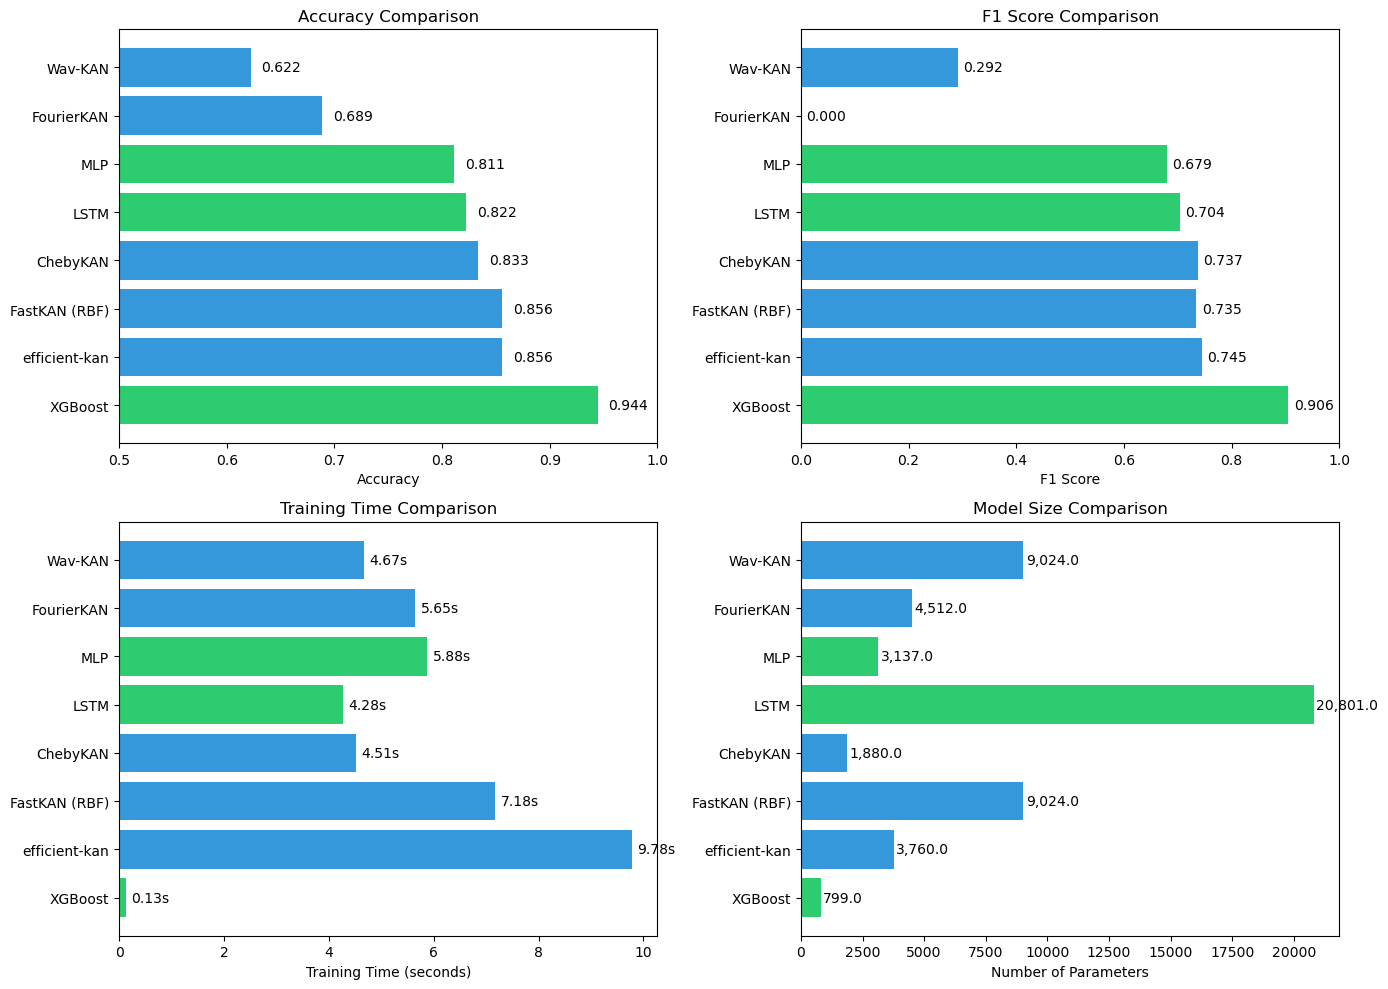


🟢 Green = Baseline models | 🔵 Blue = KAN variants


In [16]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color palette - distinguish baselines vs KANs
colors = ['#2ecc71' if m in ['XGBoost', 'MLP', 'LSTM'] else '#3498db' for m in results_df['Model']]

# 1. Accuracy Comparison
ax1 = axes[0, 0]
bars = ax1.barh(results_df['Model'], results_df['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy Comparison')
ax1.set_xlim(0.5, 1.0)
for bar, val in zip(bars, results_df['Accuracy']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 2. F1 Score Comparison
ax2 = axes[0, 1]
bars = ax2.barh(results_df['Model'], results_df['F1 Score'], color=colors)
ax2.set_xlabel('F1 Score')
ax2.set_title('F1 Score Comparison')
ax2.set_xlim(0, 1.0)
for bar, val in zip(bars, results_df['F1 Score']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center')

# 3. Training Time Comparison
ax3 = axes[1, 0]
bars = ax3.barh(results_df['Model'], results_df['Train Time (s)'], color=colors)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_title('Training Time Comparison')
for bar, val in zip(bars, results_df['Train Time (s)']):
    ax3.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}s', va='center')

# 4. Parameter Count Comparison
ax4 = axes[1, 1]
bars = ax4.barh(results_df['Model'], results_df['Parameters'], color=colors)
ax4.set_xlabel('Number of Parameters')
ax4.set_title('Model Size Comparison')
for bar, val in zip(bars, results_df['Parameters']):
    ax4.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center')

plt.tight_layout()
plt.savefig('../figures/benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Legend
print("\n🟢 Green = Baseline models | 🔵 Blue = KAN variants")

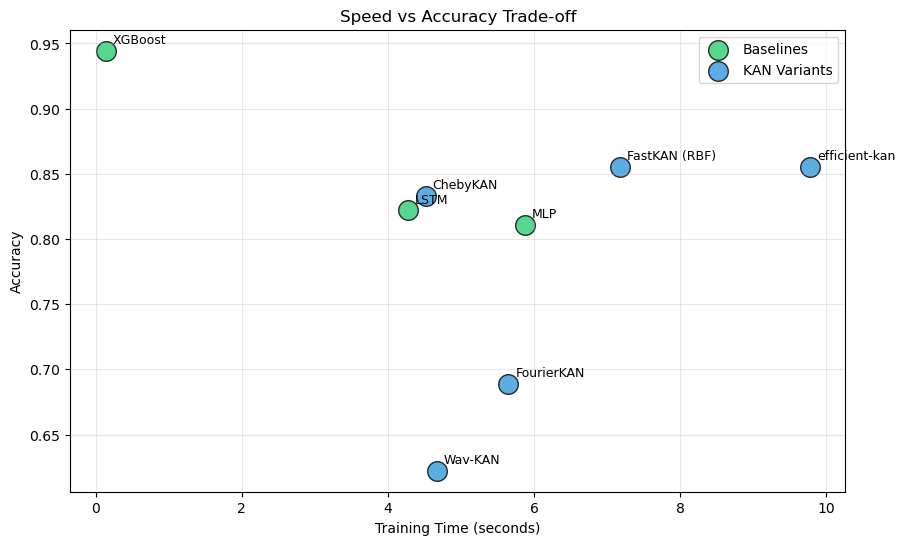

In [17]:
# Speed vs Accuracy tradeoff plot
plt.figure(figsize=(10, 6))

baseline_mask = results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])

plt.scatter(results_df[baseline_mask]['Train Time (s)'], 
            results_df[baseline_mask]['Accuracy'], 
            c='#2ecc71', s=200, label='Baselines', alpha=0.8, edgecolors='black')

plt.scatter(results_df[~baseline_mask]['Train Time (s)'], 
            results_df[~baseline_mask]['Accuracy'], 
            c='#3498db', s=200, label='KAN Variants', alpha=0.8, edgecolors='black')

for _, row in results_df.iterrows():
    plt.annotate(row['Model'], (row['Train Time (s)'], row['Accuracy']), 
                 textcoords="offset points", xytext=(5, 5), fontsize=9)

plt.xlabel('Training Time (seconds)')
plt.ylabel('Accuracy')
plt.title('Speed vs Accuracy Trade-off')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../figures/speed_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Key Findings

In [18]:
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

best_model = results_df.iloc[0]
fastest_model = results_df.loc[results_df['Train Time (s)'].idxmin()]
best_kan = results_df[~results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])].iloc[0] if len(results_df[~results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])]) > 0 else None

print(f"\n🏆 Best Overall Accuracy: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"⚡ Fastest Training: {fastest_model['Model']} ({fastest_model['Train Time (s)']:.2f}s)")
if best_kan is not None:
    print(f"🧠 Best KAN Variant: {best_kan['Model']} ({best_kan['Accuracy']:.4f})")

# KAN vs Baseline comparison
kan_models = results_df[~results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])]
baseline_models = results_df[results_df['Model'].isin(['XGBoost', 'MLP', 'LSTM'])]

if len(kan_models) > 0 and len(baseline_models) > 0:
    print(f"\n📊 Average KAN Accuracy: {kan_models['Accuracy'].mean():.4f}")
    print(f"📊 Average Baseline Accuracy: {baseline_models['Accuracy'].mean():.4f}")


KEY FINDINGS

🏆 Best Overall Accuracy: XGBoost (0.9444)
⚡ Fastest Training: XGBoost (0.13s)
🧠 Best KAN Variant: efficient-kan (0.8556)

📊 Average KAN Accuracy: 0.7711
📊 Average Baseline Accuracy: 0.8593


---
## Next Steps
1. Apply these models to the **player_injuries_impact.csv** (real-world data)
2. Perform hyperparameter tuning on best performers
3. Add cross-validation for more robust estimates